# ESS Battery Health 

데이터셋 : Stanford & MIT - *Data-driven prediction of battery cycle life before capacity degradation* (Nature Energy, 2019)  

In [20]:
#!pip install mat73 h5py

In [21]:
import numpy as np
import pandas as pd
import mat73                      # MATLAB v7.3 (HDF5) 형식 로드용
import scipy.io as sio            # MATLAB v7.2 이하 형식 로드용 (fallback)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from importlib.util import find_spec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [22]:
# 데이터 경로 설정
DATA_DIR = os.path.expanduser(
    "/Users/sumin/Documents/workspace/datasci/battery"
)

files = sorted(os.listdir(DATA_DIR))
print(f"데이터 경로 : {DATA_DIR}")
print(f"파일 목록 :")
for f in files:
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024**3)
    print(f"   {f}  ({size_mb:.1f} GB)")

데이터 경로 : /Users/sumin/Documents/workspace/datasci/battery
파일 목록 :
   2017-05-12_batchdata_updated_struct_errorcorrect.mat  (2.8 GB)
   2018-02-20_batchdata_updated_struct_errorcorrect.mat  (1.9 GB)
   2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat  (0.1 GB)
   2018-04-12_batchdata_updated_struct_errorcorrect.mat  (3.0 GB)


## Loading

- `.mat` 파일은 MATLAB 형식이며, 이 파일은 **MATLAB v7.3(HDF5)** 포맷임
- 먼저 `scipy.io.loadmat()`을 시도하고, v7.3이면 `mat73`로 fallback 함
- 파일 크기가 크므로 **Batch 1** 하나만 먼저 로드함

In [23]:
# 데이터 경로 설정
batch1_path = os.path.join(DATA_DIR, '2017-05-12_batchdata_updated_struct_errorcorrect.mat')
batch2_path = os.path.join(DATA_DIR, '2018-02-20_batchdata_updated_struct_errorcorrect.mat')
batch3_path = os.path.join(DATA_DIR, '2018-04-12_batchdata_updated_struct_errorcorrect.mat')

def load_mat(path):
    try:
        data = mat73.loadmat(path)
        print("  로드 완료 (MATLAB v7.3 / HDF5 형식)")
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
        print("  로드 완료 (MATLAB v7.2 이하 형식)")
    return data

print("Batch 1 로딩 중...")
mat1 = load_mat(batch1_path)

print("Batch 2 로딩 중...")
mat2 = load_mat(batch2_path)

print("Batch 3 로딩 중...")
mat3 = load_mat(batch3_path)

print("\n최상위 키")
for i, m in enumerate([mat1, mat2, mat3], 1):
    print(f"  Batch {i} : {list(m.keys())}")

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

  로드 완료 (MATLAB v7.3 / HDF5 형식)
Batch 2 로딩 중...


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

  로드 완료 (MATLAB v7.3 / HDF5 형식)
Batch 3 로딩 중...
  로드 완료 (MATLAB v7.3 / HDF5 형식)

최상위 키
  Batch 1 : ['batch', 'batch_date']
  Batch 2 : ['batch', 'batch_date']
  Batch 3 : ['batch', 'batch_date']


## 데이터 타입 및 구조 확인

이 데이터셋은 `batch` 키 아래 배터리 셀 배열로 구성되어 있음

In [24]:
def parse_batch(mat):
    """mat 딕셔너리에서 batch 리스트 추출 (mat73 / scipy 양쪽 처리)"""
    batch = mat['batch']
    if isinstance(batch, dict):
        keys = list(batch.keys())
        n_cells = len(batch[keys[0]])
        batch = [{k: batch[k][i] for k in keys} for i in range(n_cells)]
    return batch

batch1 = parse_batch(mat1)
batch2 = parse_batch(mat2)
batch3 = parse_batch(mat3)

for i, b in enumerate([batch1, batch2, batch3], 1):
    print(f"Batch {i} : {len(b)}개 셀,  키 : {list(b[0].keys())}")

Batch 1 : 46개 셀,  키 : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']
Batch 2 : 47개 셀,  키 : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']
Batch 3 : 46개 셀,  키 : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [25]:
# cycle_life 존재 여부 및 값 확인
for bname, batch in [('Batch 1', batch1), ('Batch 2', batch2), ('Batch 3', batch3)]:
    has_key   = sum(1 for c in batch if 'cycle_life' in c)
    nan_count = sum(1 for c in batch if 'cycle_life' in c and pd.isna(c['cycle_life']))
    missing   = len(batch) - has_key
    print(f"{bname}  총 {len(batch)}셀  |  cycle_life 있음: {has_key}  |  NaN: {nan_count}  |  키 없음: {missing}")
    # 실제 값 샘플
    sample = [(i, c.get('cycle_life')) for i, c in enumerate(batch[:5])]
    print(f"  샘플(0~4): {sample}")


Batch 1  총 46셀  |  cycle_life 있음: 46  |  NaN: 0  |  키 없음: 0
  샘플(0~4): [(0, array(1190.)), (1, array(1179.)), (2, array(1177.)), (3, array(1226.)), (4, array(1227.))]
Batch 2  총 47셀  |  cycle_life 있음: 47  |  NaN: 8  |  키 없음: 0
  샘플(0~4): [(0, array(477.)), (1, array(491.)), (2, array(424.)), (3, array(499.)), (4, array(444.))]
Batch 3  총 46셀  |  cycle_life 있음: 46  |  NaN: 2  |  키 없음: 0
  샘플(0~4): [(0, array(1009.)), (1, array(1063.)), (2, array(1267.)), (3, array(1115.)), (4, array(1048.))]


In [26]:
# 단일 셀 구조 상세 확인 (Batch 1 기준)
cell0 = batch1[0]

print("=" * 55)
print("배터리 셀[0] 구조  (Batch 1)")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:20s} : ndarray {val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:20s} : dict  keys={list(val.keys())[:5]}")
    elif isinstance(val, list):
        print(f"  {key:20s} : list  len={len(val)}")
    else:
        print(f"  {key:20s} : {type(val).__name__}  = {val}")

배터리 셀[0] 구조  (Batch 1)
  Vdlin                : ndarray (1000,)
  barcode              : NoneType  = None
  channel_id           : NoneType  = None
  cycle_life           : ndarray ()
  cycles               : dict  keys=['I', 'Qc', 'Qd', 'Qdlin', 'T']
  policy               : str  = 3_6C-80PER_3_6C
  policy_readable      : str  = 3.6C(80%)-3.6C
  summary              : dict  keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax']


In [27]:
# cycles 내부 구조 확인 (Batch 1 기준)
cycles_raw = batch1[0]['cycles']

if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n)]
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"사이클[0] 키 : {list(cycles[0].keys())}")
for k, v in cycles[0].items():
    shape = np.array(v).shape if not isinstance(v, str) else v
    print(f"  {k:15s} : {shape}")

총 사이클 수 : 1189
사이클[0] 키 : ['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  I               : ()
  Qc              : ()
  Qd              : ()
  Qdlin           : ()
  T               : ()
  Tdlin           : ()
  V               : ()
  discharge_dQdV  : ()
  t               : ()


## Summary 데이터 추출

각 배터리의 `summary` 필드에서 사이클별 요약 지표를 DataFrame으로 변환

In [28]:
def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환"""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d

def _get(summary, *keys):
    """summary dict에서 후보 키 순서대로 첫 번째 존재하는 값을 반환, 없으면 None"""
    for k in keys:
        if k in summary:
            return np.array(summary[k])
    return None

def extract_summary(batch, batch_id=None):
    """모든 배터리 셀의 summary 데이터를 DataFrame으로 변환 (배치 간 키 차이 허용)"""
    records = []
    for i, cell in enumerate(batch):
        summary = cell['summary']

        # QDischarge / QD 등 배치별 키 이름 차이 대응
        qd   = _get(summary, 'QDischarge', 'QD')
        qc   = _get(summary, 'QCharge', 'QC')
        ir   = _get(summary, 'IR')
        tmax = _get(summary, 'Tmax')
        tavg = _get(summary, 'Tavg')
        tmin = _get(summary, 'Tmin')
        ct   = _get(summary, 'chargetime')

        if qd is None:
            print(f"  [경고] Cell {i}: QDischarge 키 없음 → 건너뜀. summary 키: {list(summary.keys())}")
            continue

        n = len(qd)

        # cycle_life: 키가 없거나 NaN이면 실제 사이클 수로 대체
        cl_val = cell.get('cycle_life')
        try:
            cl_scalar = float(np.array(cl_val).flat[0])
            if np.isnan(cl_scalar):
                continue  # cycle_life 없는 셀 제외
            cycle_life = int(cl_scalar)
        except (TypeError, ValueError):
            continue  # 변환 불가 셀 제외

        policy = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')

        def safe(arr, idx):
            if arr is None:
                return np.nan
            return arr[idx] if idx < len(arr) else np.nan

        for c in range(n):
            records.append({
                'cell_id'         : i,
                'cycle'           : c + 1,
                'cycle_life'      : cycle_life,
                'charging_policy' : policy,
                'QD'              : safe(qd, c),
                'QC'              : safe(qc, c),
                'IR'              : safe(ir, c),
                'Tmax'            : safe(tmax, c),
                'Tavg'            : safe(tavg, c),
                'Tmin'            : safe(tmin, c),
                'chargetime'      : safe(ct, c),
            })
    return pd.DataFrame(records)


In [29]:
df1 = extract_summary(batch1)
df2 = extract_summary(batch2)
df3 = extract_summary(batch3)

for i, df in enumerate([df1, df2, df3], 1):
    print(f"Batch {i}  shape : {df.shape}")

df1.head()

Batch 1  shape : (38811, 11)
Batch 2  shape : (23034, 11)
Batch 3  shape : (46581, 11)


,cell_id,cycle,cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,0,1,1190,3.6C(80%)-3.6C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,2,1190,3.6C(80%)-3.6C,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250
2,0,3,1190,3.6C(80%)-3.6C,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777
3,0,4,1190,3.6C(80%)-3.6C,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167
4,0,5,1190,3.6C(80%)-3.6C,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442


In [30]:
for i, df in enumerate([df1, df2, df3], 1):
    print(f"\n{'='*55}")
    print(f"  Batch {i}  기본 통계")
    print(f"{'='*55}")
    display(df.describe().round(3))


  Batch 1  기본 통계


,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
count,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000
mean,20.771,442.121,884.241,1.045,1.045,0.017,37.322,33.404,30.589,11.510
std,13.469,276.876,186.940,0.059,0.061,0.001,2.760,1.964,1.575,4.518
min,0.000,1.000,534.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,9.000,211.000,731.000,1.036,1.036,0.017,35.961,32.438,29.938,10.653
50%,21.000,422.000,870.000,1.063,1.062,0.017,37.599,33.471,30.390,11.208
75%,32.000,640.000,1017.000,1.076,1.076,0.017,39.107,34.472,31.200,12.092
max,45.000,1226.000,1227.000,2.884,2.966,0.022,43.419,38.414,34.851,419.873



  Batch 2  기본 통계


,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
count,23034.000,23034.000,23034.000,23034.000,23034.000,23034.000,23034.000,23034.000,23034.000,23034.000
mean,22.752,339.595,650.175,1.050,1.048,0.014,37.051,33.316,30.725,12.609
std,14.219,252.311,265.142,0.067,0.059,0.007,2.562,1.455,1.320,81.758
min,0.000,1.000,392.000,0.825,0.829,0.000,29.528,29.054,0.000,10.015
25%,9.000,148.000,449.000,1.030,1.027,0.015,35.106,32.328,30.236,10.051
50%,24.000,296.000,491.000,1.076,1.065,0.017,37.105,33.292,30.629,10.175
75%,33.000,447.000,841.000,1.097,1.085,0.017,38.963,34.068,31.164,10.366
max,46.000,1252.000,1186.000,1.121,1.174,0.023,42.950,38.872,34.871,3934.705



  Batch 3  기본 통계


,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
count,46581.000,46581.000,46581.000,46581.000,46581.000,46581.000,46581.000,46581.000,46581.000,46581.000
mean,22.930,575.300,1150.600,1.028,1.028,0.016,38.492,35.443,32.562,10.415
std,13.964,388.418,349.576,0.044,0.044,0.001,2.479,1.717,1.016,0.720
min,0.000,1.000,541.000,0.880,0.880,0.010,31.209,31.003,28.032,10.024
25%,10.000,265.000,858.000,1.014,1.014,0.015,36.659,34.112,31.818,10.043
50%,22.000,530.000,1048.000,1.043,1.042,0.015,38.964,35.480,32.447,10.046
75%,36.000,807.000,1284.000,1.059,1.059,0.016,40.216,36.728,33.324,10.926
max,45.000,1934.000,1935.000,1.100,1.103,0.021,44.663,41.440,36.691,24.003


In [31]:
print("결측치 현황")
for i, df in enumerate([df1, df2, df3], 1):
    nulls = df.isnull().sum()
    print(f"\nBatch {i} :")
    print(nulls[nulls > 0] if nulls.any() else "  결측치 없음")

결측치 현황

Batch 1 :
  결측치 없음

Batch 2 :
  결측치 없음

Batch 3 :
  결측치 없음


In [32]:
for i, df in enumerate([df1, df2, df3], 1):
    print(f"Batch {i}  배터리 셀 수 : {df['cell_id'].nunique()},  "
          f"충전 정책 종류 : {df['charging_policy'].nunique()}")

Batch 1  배터리 셀 수 : 46,  충전 정책 종류 : 23
Batch 2  배터리 셀 수 : 39,  충전 정책 종류 : 12
Batch 3  배터리 셀 수 : 44,  충전 정책 종류 : 8


## EDA(Basic)

### 1. Cycle Life 분포


Batch 1 Cycle Life 통계:
count      46.0
mean      844.7
std       184.6
min       534.0
25%       703.2
50%       858.5
75%       914.2
max      1227.0
Name: cycle_life, dtype: float64

Batch 2 Cycle Life 통계:
count      39.0
mean      565.7
std       222.2
min       392.0
25%       439.5
50%       472.0
75%       508.5
max      1186.0
Name: cycle_life, dtype: float64

Batch 3 Cycle Life 통계:
count      44.0
mean     1059.7
std       313.9
min       541.0
25%       828.0
50%      1005.5
75%      1155.2
max      1935.0
Name: cycle_life, dtype: float64


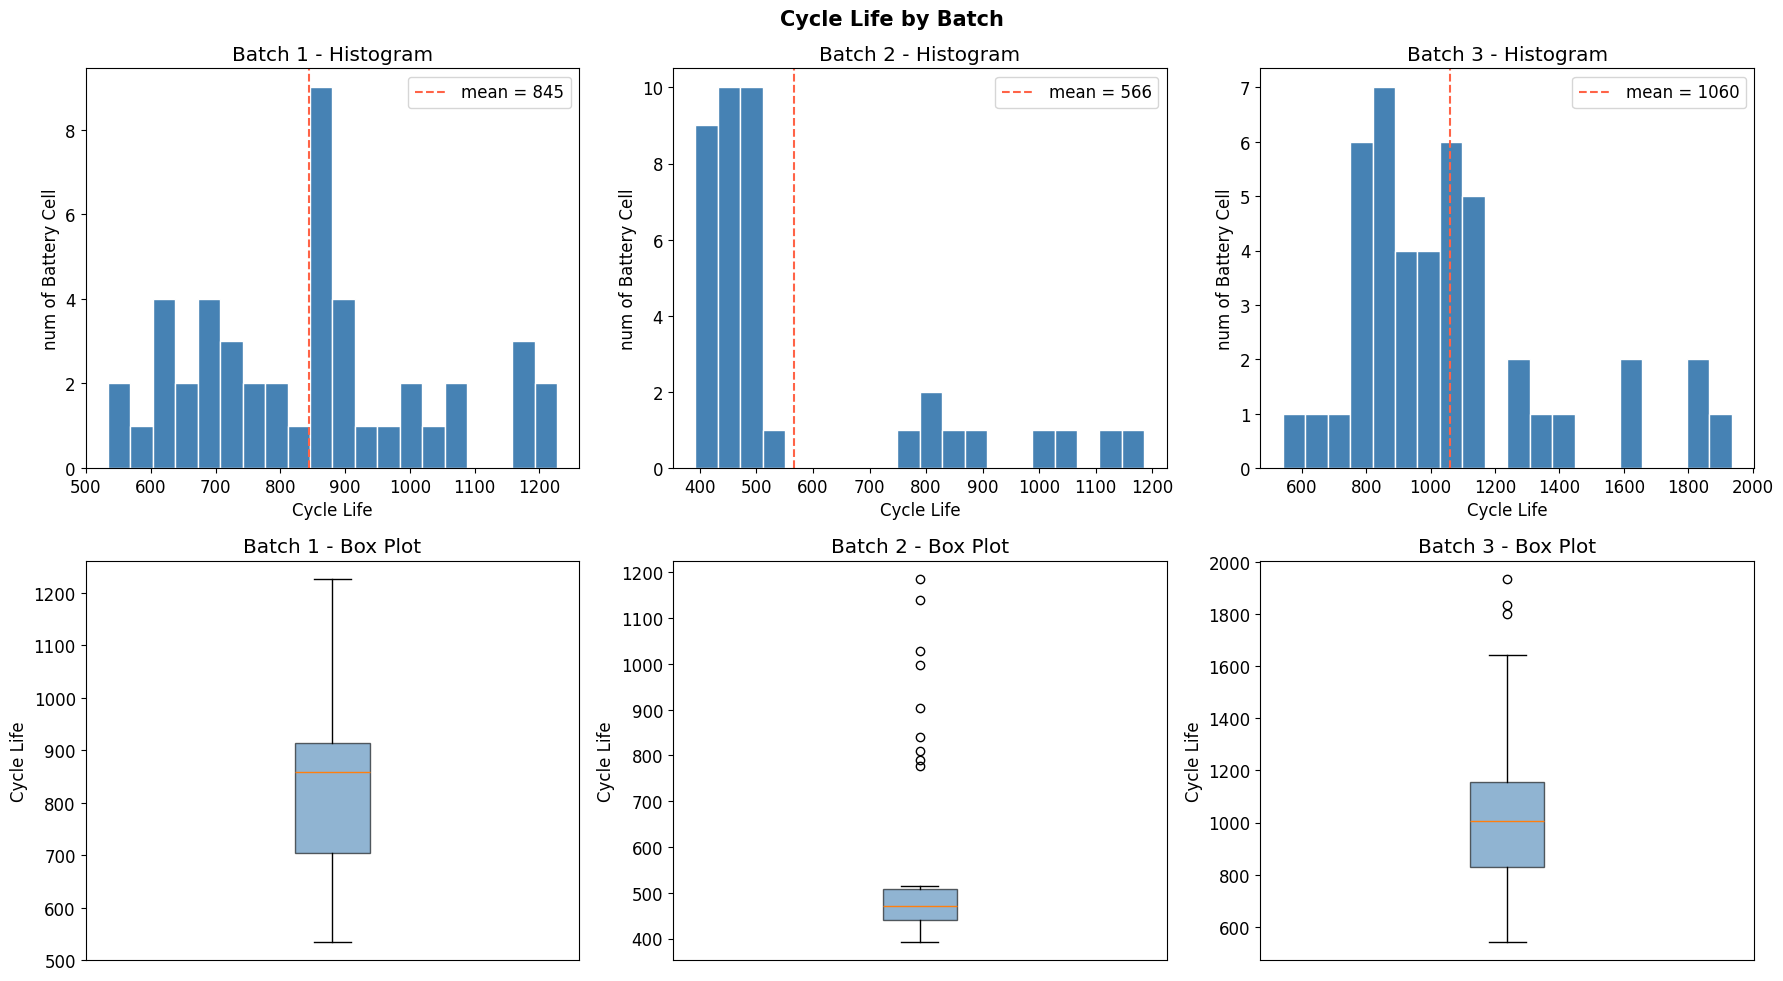

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, (bname, df) in enumerate([('Batch 1', df1), ('Batch 2', df2), ('Batch 3', df3)]):
    cycle_life_df = df.drop_duplicates('cell_id')[['cell_id', 'cycle_life', 'charging_policy']]

    axes[0, col].hist(cycle_life_df['cycle_life'], bins=20, color='steelblue', edgecolor='white')
    axes[0, col].set_title(f'{bname} - Histogram')
    axes[0, col].set_xlabel('Cycle Life')
    axes[0, col].set_ylabel('num of Battery Cell')
    mean_val = cycle_life_df['cycle_life'].mean()
    axes[0, col].axvline(mean_val, color='tomato', linestyle='--', label=f'mean = {mean_val:.0f}')
    axes[0, col].legend()

    axes[1, col].boxplot(cycle_life_df['cycle_life'], patch_artist=True,
                         boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[1, col].set_title(f'{bname} - Box Plot')
    axes[1, col].set_ylabel('Cycle Life')
    axes[1, col].set_xticks([])

    print(f"\n{bname} Cycle Life 통계:")
    print(cycle_life_df['cycle_life'].describe().round(1))

plt.suptitle('Cycle Life by Batch', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

[describe] 
- 배터리 평균 수명 약 845 사이클 (단명 534 ~ 장수 1227)
- 평균 vs 중앙값 차이 없음 (데이터 왜곡/편향 적은 편) 
- IQR 통해 절반의 배터리가 703 ~ 914 범위에 집중 

[plot]
- Histogram : 845 근처에 가장 몰려 있고 600대와 1,200대에 일부 분포. 완전한 정규분포는 아님 
- Box plot : 
    - Upper whisker = |75%(914) - max(1227)| = 313
    - Lower whisker = |25%(703) - min(534) | = 169
- Upper가 큼 -> 장수 배터리의 수명 편차가 더 큼 -> 좋은 충전 조건을 만나면 수명이 크게 늘어날 수 있지만, 그 폭이 불규칙함  
- Lower는 상대적으로 짧음 -> 단명 배터리가 534~703 구간에 비교적 일정하게 분포 -> 나쁜 충전 조건에서는 수명이 어느 정도 예측 가능한 범위로 떨어질 수 있음 

[to modeling]
- 수명이 긴 배터리일수록 예측 난이도 있음 
- residual 분석을 함께 진행하는 것도 필요할 수 있음 

### 2. 열화 곡선 - 방전 용량(QD) 감소 패턴

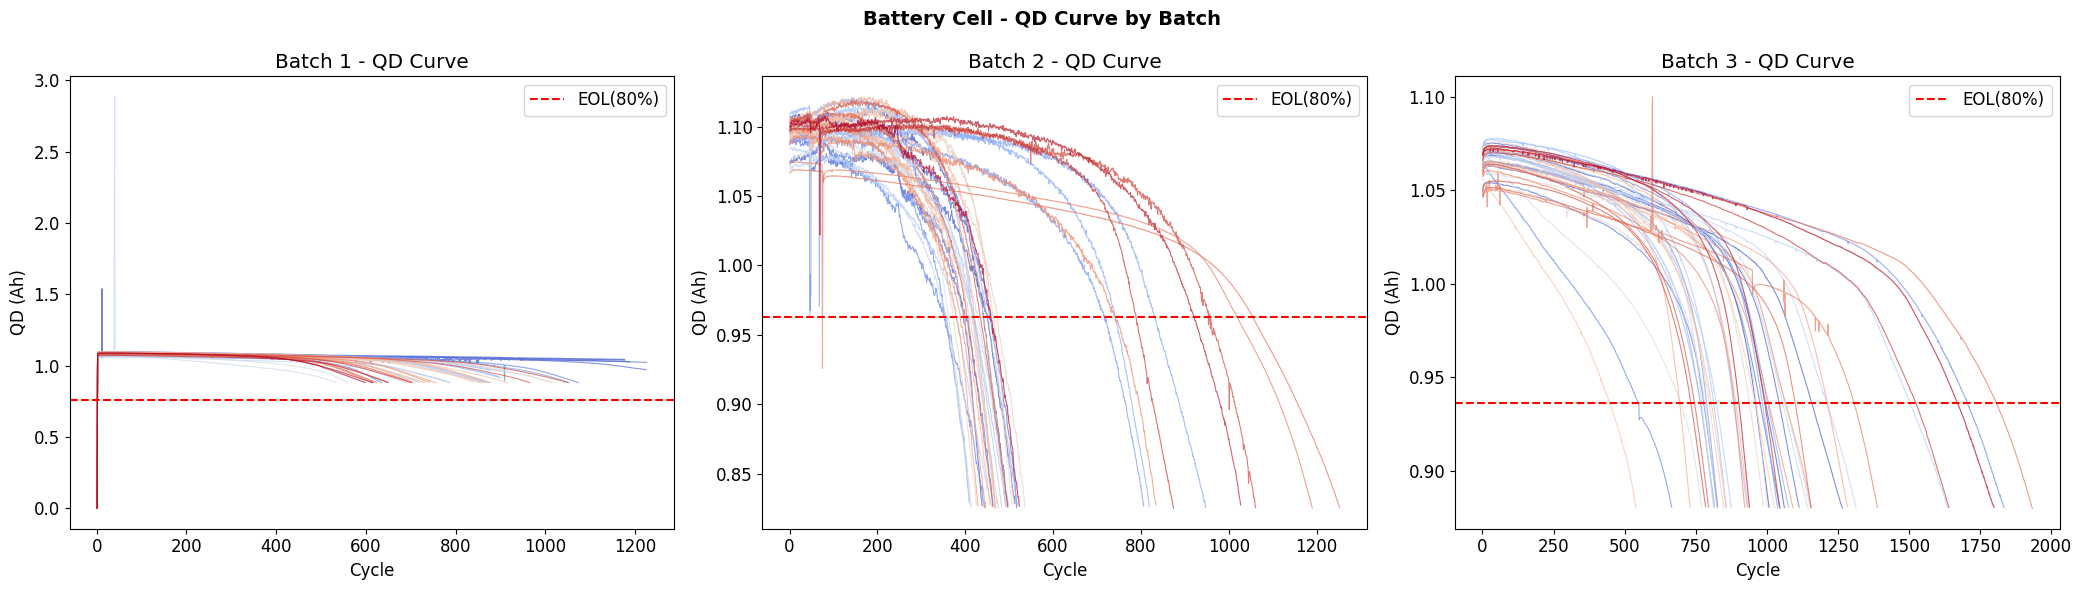

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, (bname, df) in zip(axes, [('Batch 1', df1), ('Batch 2', df2), ('Batch 3', df3)]):
    cell_ids = df['cell_id'].unique()
    colors = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

    for i, cid in enumerate(cell_ids):
        sub = df[df['cell_id'] == cid]
        ax.plot(sub['cycle'], sub['QD'], color=colors[i], linewidth=0.8, alpha=0.7)

    nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].mean().mean()
    ax.axhline(y=0.88 * nominal, color='red', linestyle='--', linewidth=1.5, label='EOL(80%)')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('QD (Ah)')
    ax.set_title(f'{bname} - QD Curve')
    ax.legend()

plt.suptitle('Battery Cell - QD Curve by Batch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

[plot]
- 초기 이상값 스파이크 (cycle 0 ~ 50 구간) : 정상적인 배터리 용량을 벗어나므로, outlier filtering 고려 대상 
- 열화 패턴 : 대부분의 셀이 약 1.1Ah에서 시작해 사이클이 늘어날수록 원만하게 감소함. 논문에서 언급된 용량 열화(Capacity Fade) 곡선 형태 확인됨 
- 색상 분포 : 파란색은 장수 배터리, 빨간색은 단명 배터리로 구분됨. 사이클 600 이후에 파란색이 높게 유지되는 것으로 보임 

Batch 1  nominal=1.0796 Ah,  제거 48행 (0.12%)
Batch 2  nominal=1.0962 Ah,  제거 944행 (4.10%)
Batch 3  nominal=1.0664 Ah,  제거 0행 (0.00%)


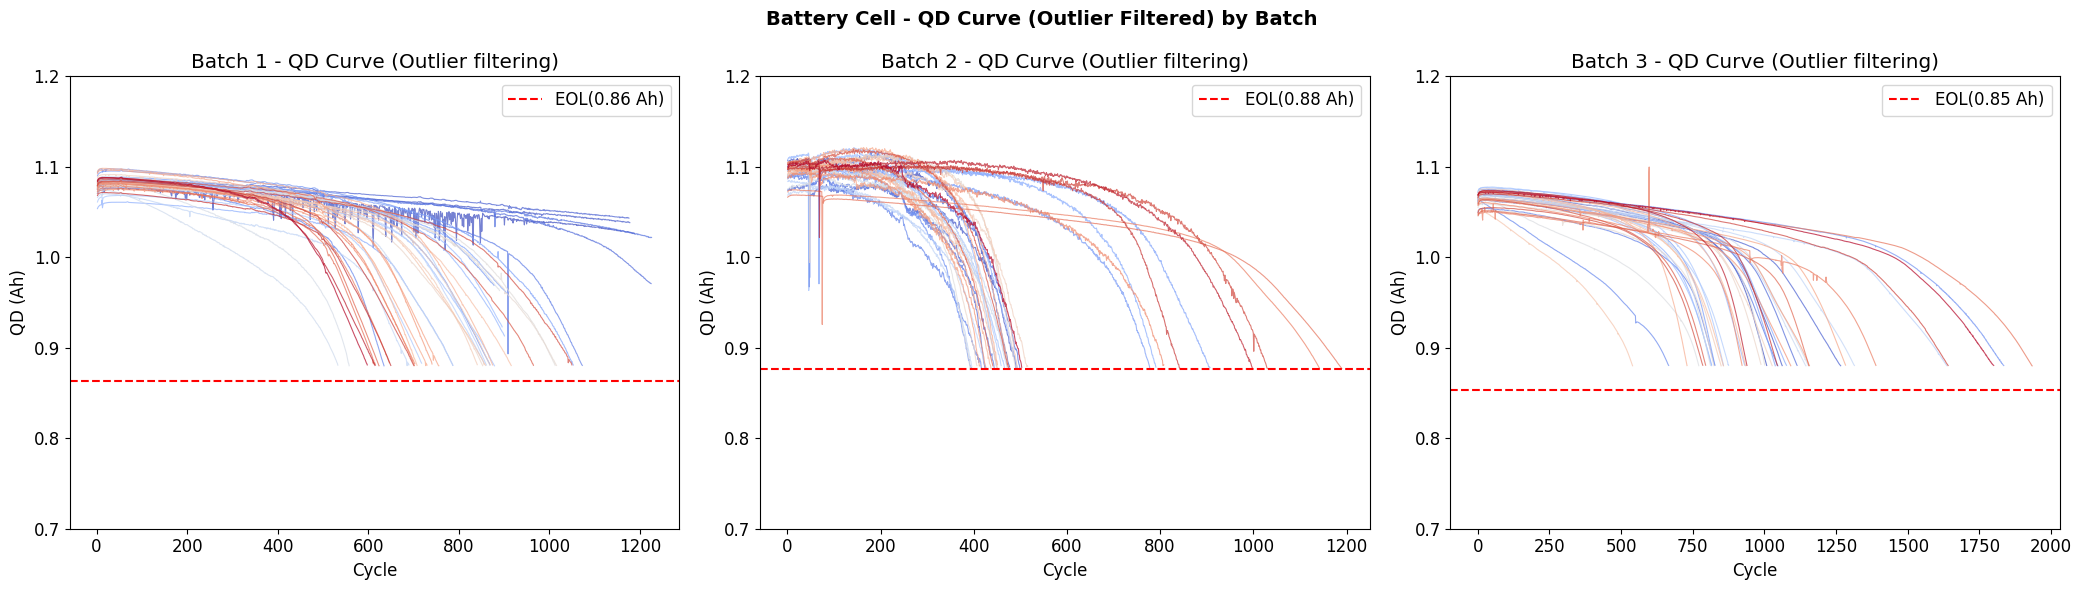

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, (bname, df) in zip(axes, [('Batch 1', df1), ('Batch 2', df2), ('Batch 3', df3)]):
    nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].median().median()
    lower   = nominal * 0.80
    upper   = nominal * 1.20
    df_clean = df[df['QD'].between(lower, upper)].copy()

    removed_pct = (len(df) - len(df_clean)) / len(df) * 100
    print(f"{bname}  nominal={nominal:.4f} Ah,  제거 {len(df)-len(df_clean)}행 ({removed_pct:.2f}%)")

    cell_ids = df_clean['cell_id'].unique()
    colors   = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

    for i, cid in enumerate(cell_ids):
        sub = df_clean[df_clean['cell_id'] == cid]
        ax.plot(sub['cycle'], sub['QD'], color=colors[i], linewidth=0.8, alpha=0.7)

    ax.axhline(y=nominal * 0.8, color='red', linestyle='--',
               linewidth=1.5, label=f'EOL({nominal*0.8:.2f} Ah)')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('QD (Ah)')
    ax.set_title(f'{bname} - QD Curve (Outlier filtering)')
    ax.set_ylim(0.7, 1.2)
    ax.legend()

plt.suptitle('Battery Cell - QD Curve (Outlier Filtered) by Batch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

[plot]
- cycle  1 ~  50 : 모든 셀이 1.06~1.10Ah 범위에서 시작하며 초기 용량이 매우 균일함 -> 셀 간 초기 상태 차이 거의 없음 
- cycle 50 ~ 400 : 회색 계열 셀들이 달느 셀보다 빠르게 하강 
- cycle 400 ~    : 
    - 붉은 계열 : cycle 600 부근에서 EOL 기준선에 도달하며 조기 종료 
    - 파란 계열 : cycle 1,000 이후에도 1.0Ah 수준을 유지하며 장수 

[to modeling]
- 초기 구간에는 모든 선이 거의 겹쳐 보임 -> QD 값만으로는 차이를 확인할 수 없음 -> ΔQ(V) 확인 필요 

### 3. 내부 저항(IR) 변화 - 열화 지표

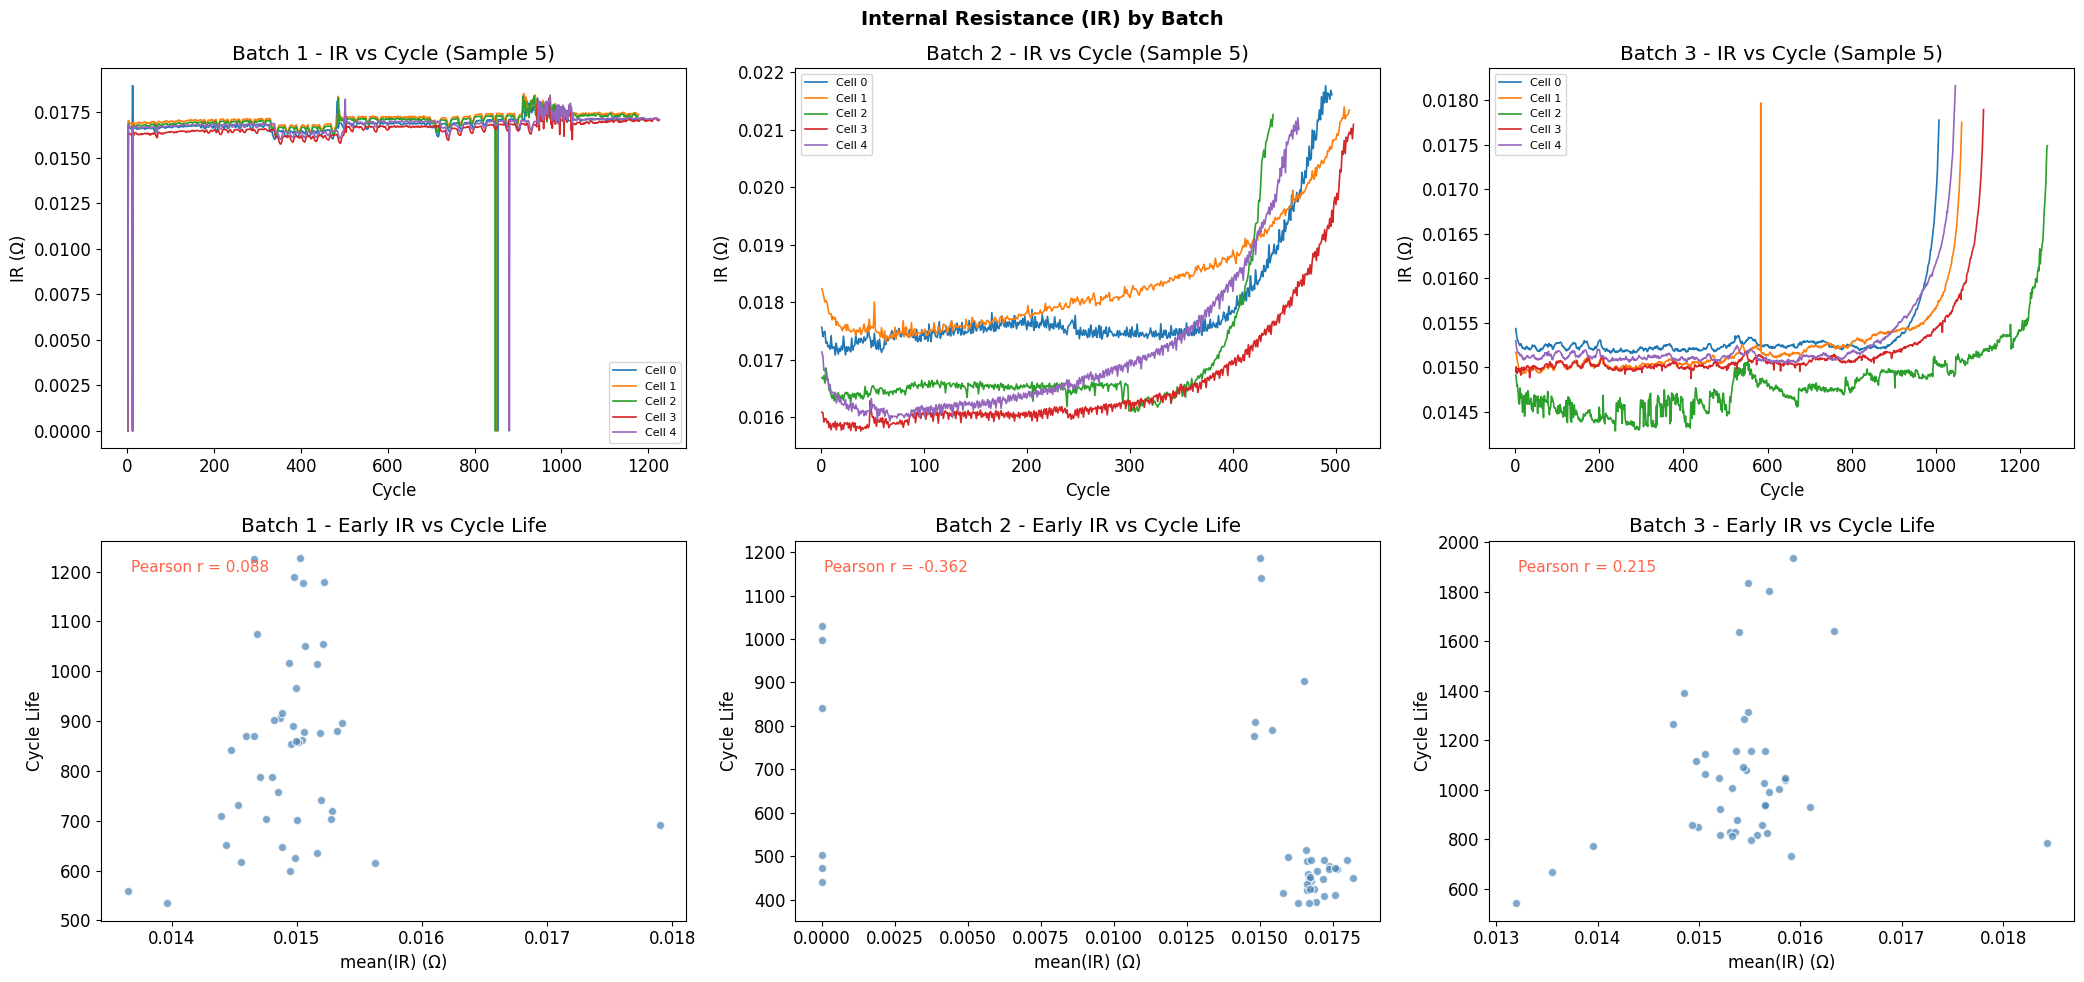

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(21, 10))

for col, (bname, df) in enumerate([('Batch 1', df1), ('Batch 2', df2), ('Batch 3', df3)]):
    cycle_life_df = df.drop_duplicates('cell_id')[['cell_id', 'cycle_life', 'charging_policy']]
    cell_ids = df['cell_id'].unique()

    for cid in cell_ids[:5]:
        sub = df[df['cell_id'] == cid]
        axes[0, col].plot(sub['cycle'], sub['IR'], label=f'Cell {cid}', linewidth=1.2)
    axes[0, col].set_xlabel('Cycle')
    axes[0, col].set_ylabel('IR (Ω)')
    axes[0, col].set_title(f'{bname} - IR vs Cycle (Sample 5)')
    axes[0, col].legend(fontsize=8)

    early_ir = df[df['cycle'] <= 10].groupby('cell_id')['IR'].mean().reset_index()
    early_ir.columns = ['cell_id', 'early_IR']
    merged = cycle_life_df.merge(early_ir, on='cell_id')
    axes[1, col].scatter(merged['early_IR'], merged['cycle_life'],
                         alpha=0.7, color='steelblue', edgecolors='white')
    axes[1, col].set_xlabel('mean(IR) (Ω)')
    axes[1, col].set_ylabel('Cycle Life')
    axes[1, col].set_title(f'{bname} - Early IR vs Cycle Life')
    corr = merged['early_IR'].corr(merged['cycle_life'])
    axes[1, col].text(0.05, 0.95, f'Pearson r = {corr:.3f}',
                      transform=axes[1, col].transAxes, fontsize=11,
                      verticalalignment='top', color='tomato')

plt.suptitle('Internal Resistance (IR) by Batch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

[plot] - Sampling
- 내부저항(IR)이 전체 구간에서 평탄함. 배터리가 열화될수록 IR이 증가해야 하는데 해당 샘플에서는 확인되지 않음 
    - 샘플링 배터리는 IR 변화가 용량 변화에 비해 상대적으로 적음 -> 흑연 음극 구조 특징 
    - 사이클 800~900 부근의 스파이크는 측정 노이즈 또는 셀 교체 시점으로 해석 가능 

[plot] - correlation 
- 상관계수가 0.088이고, scatter 분포를 통해 상관관계 전혀 없음 

[to modeling]
- IR 단독으로 target variable 설명할 수 없음 
- IR 변화율(ΔIR) 또는 다른 변수와의 조합/비교 통한 파생변수 고민 

### 4. 충전 정책(C-rate)과 수명의 관계

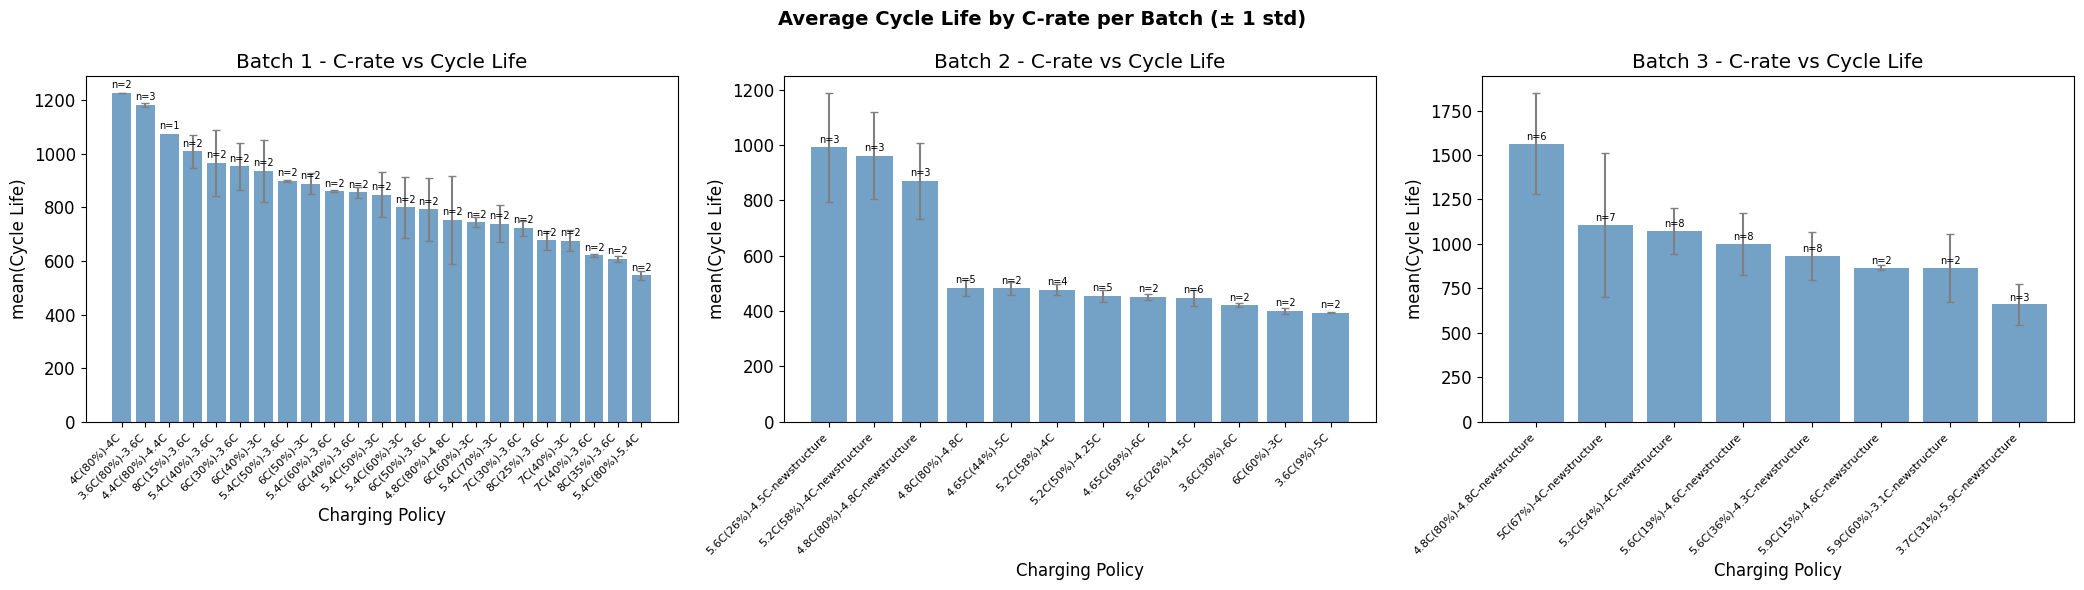

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, (bname, df) in zip(axes, [('Batch 1', df1), ('Batch 2', df2), ('Batch 3', df3)]):
    cycle_life_df = df.drop_duplicates('cell_id')[['cell_id', 'cycle_life', 'charging_policy']]
    policy_life = (cycle_life_df
                   .groupby('charging_policy')['cycle_life']
                   .agg(['mean', 'std', 'count'])
                   .sort_values('mean', ascending=False))

    x = range(len(policy_life))
    bars = ax.bar(x, policy_life['mean'],
                  yerr=policy_life['std'],
                  color='steelblue', alpha=0.75,
                  error_kw=dict(ecolor='gray', capsize=3))
    ax.set_xticks(x)
    ax.set_xticklabels(policy_life.index, rotation=45, ha='right', fontsize=8)
    ax.set_xlabel('Charging Policy')
    ax.set_ylabel('mean(Cycle Life)')
    ax.set_title(f'{bname} - C-rate vs Cycle Life')

    for bar, (_, row) in zip(bars, policy_life.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'n={int(row["count"])}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Average Cycle Life by C-rate per Batch (± 1 std)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

[remark] C-rate : 배터리 용량 대비 총전/방전 속도를 나타내는 단위 
- C-rate 
    - `1C` : 1시간 만에 완충
    - `2C` : 30분 만에 완충 
    - `4C` : 15분 만에 완충 (숫자가 클수록 빠름) 
- `4C(80%)-4C`
    - `4C` : 1단계. 0% -> 80%까지 4C 속도로 충전 
    - `(80%)` : 전환 기준. 용량 80% 도달 시 속도 변경 
    - `4C` : 2단계. 나머지 20%는 4C 속도로 충전 
- 정책 비교 
    - `4C(80%)-4C` : 처음부터 끝까지 빠르게 
    - `4C(80%)-3.6C` : 2단계만 살짝 천천히 
    - `5.4C(80%)-5.4C` : 처음부터 끝까지 매우 빠르게 -> 수명 최단

[plot]
- 왼쪽(장수)에서 오른쪽(단명)으로 갈수록 C-rate 숫자가 커지는 경향 
    - 상위 구간 (cycle 1000~1200) : `4C(80%)-4C`, `3.6C(80%)-3.6C`
    - 중위 구간 (cycle 800~900)   : `6C(40%)-3C`, `5.4C(50%)-3.6C`
    - 하위 구간 (cycle 500~600)   : `8C(35%)-3.6C`, `5.4C(80%)-5.4C`
    - 낮은 C-rate은 천천히 충전할수록 수명이 길고, 높은 C-rate로 빠르게 충전할수록 수명이 짧음 
    - Notion > Domain : 빠른 충전이 음극 팽창/수축을 가속화한다는 내용 확인 
- 2단계 충전 전략 영향도 : `8C(15%)-3.6C` vs `8C(25%)-3.6C` 
    - 그래프에서는 전환 기준을 어떻게 가져가느냐에 따라 배터리 수명에 영향을 주는 것으로 보임 
    - 그러나 샘플이 정책당 2건 밖에 되지 않으므로 "경향성" 수준으로 해석해야 함 

[to modeling]
- 충전 정책은 배터리 수명에 영향을 미치고 있음 
- 특정 정책에서는 편차가 존재하므로 추가 변수 고려 필요

### 5. 상관관계 히트맵


Batch 1  [cycle_life Corr Rank]
mean_chargetime    0.577
mean_Tavg         -0.482
mean_Tmax         -0.404
mean_QD            0.193
mean_IR            0.177
std_QD            -0.090
Name: cycle_life, dtype: float64

Batch 2  [cycle_life Corr Rank]
mean_Tavg          0.425
mean_IR           -0.353
mean_QD           -0.332
std_QD             0.171
mean_chargetime    0.087
mean_Tmax          0.019
Name: cycle_life, dtype: float64

Batch 3  [cycle_life Corr Rank]
mean_chargetime    0.637
std_QD            -0.356
mean_QD            0.217
mean_IR            0.190
mean_Tmax         -0.106
mean_Tavg         -0.022
Name: cycle_life, dtype: float64


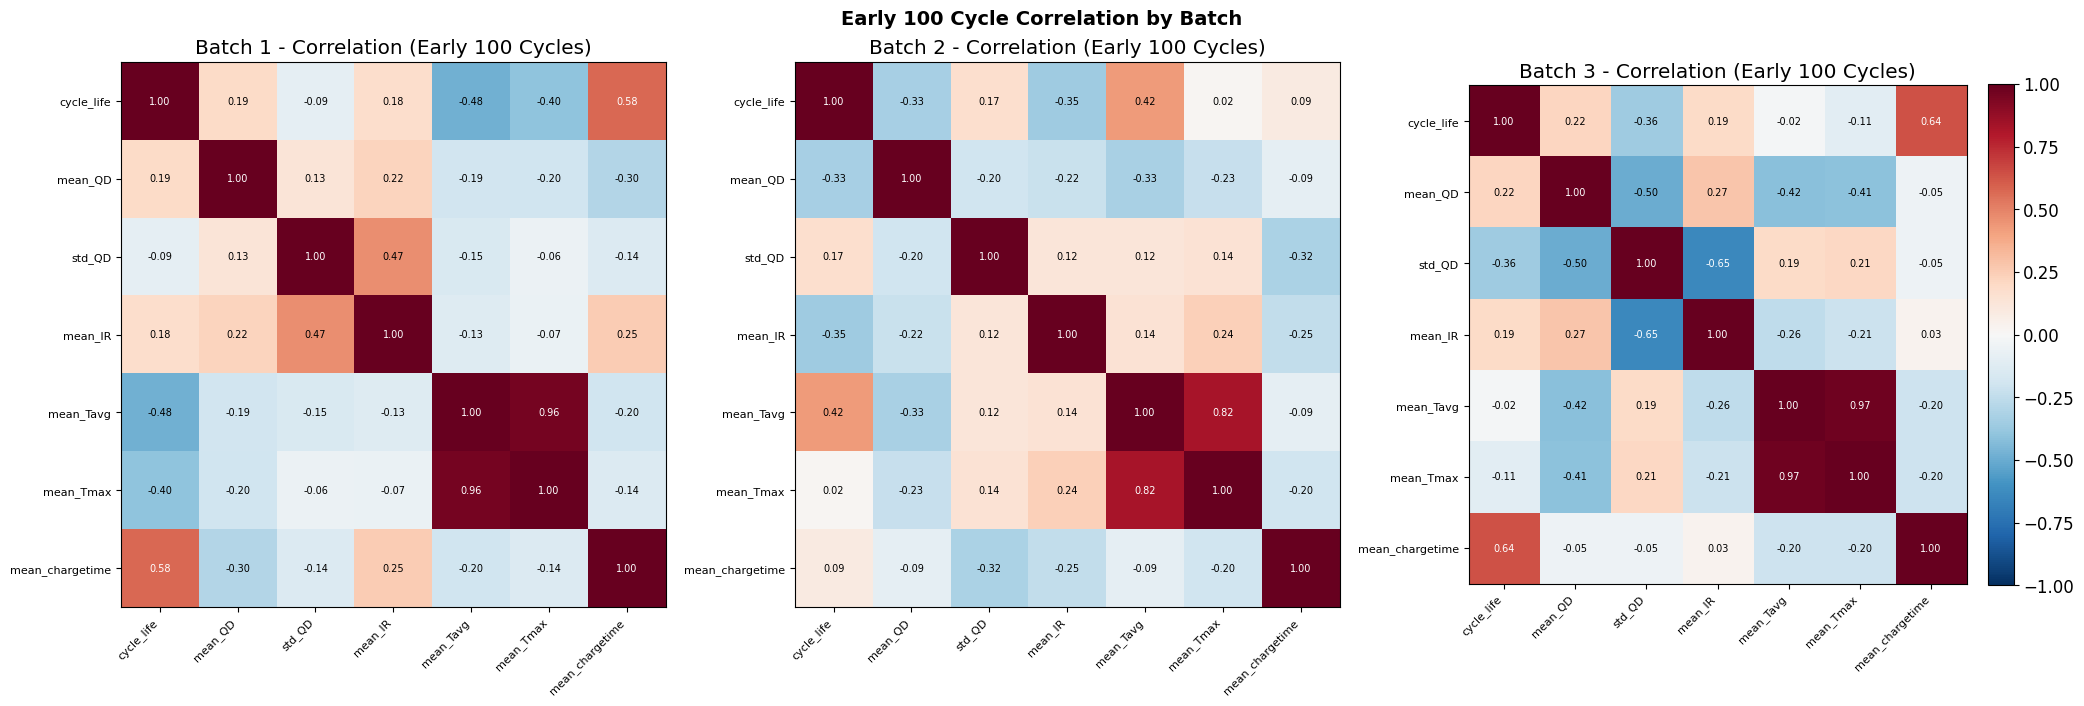

In [38]:
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, (bname, df) in zip(axes, [('Batch 1', df1), ('Batch 2', df2), ('Batch 3', df3)]):
    early = df[df['cycle'] <= 100].groupby('cell_id').agg(
        cycle_life      = ('cycle_life', 'first'),
        mean_QD         = ('QD', 'mean'),
        std_QD          = ('QD', 'std'),
        mean_IR         = ('IR', 'mean'),
        mean_Tavg       = ('Tavg', 'mean'),
        mean_Tmax       = ('Tmax', 'mean'),
        mean_chargetime = ('chargetime', 'mean'),
    ).reset_index(drop=True)

    corr_matrix = early.corr()
    im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
    labels = corr_matrix.columns.tolist()
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)

    for i in range(len(labels)):
        for j in range(len(labels)):
            val = corr_matrix.iloc[i, j]
            color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=color)

    ax.set_title(f'{bname} - Correlation (Early 100 Cycles)')

    print(f"\n{bname}  [cycle_life Corr Rank]")
    print(corr_matrix['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False).round(3))

plt.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04)
plt.suptitle('Early 100 Cycle Correlation by Batch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

[correlation]
- `mean_chargetime` : 충전 시간이 길수록 수명이 길어짐 -> C-rate과 직결. 천천히 충전(긴 충전시간) = 낮은 C-rate = 긴 수명으로 앞에서 확인 
- `mean_Tavg`, `mean_Tmax` : 온도가 높을수록 수명이 짧아짐. 빠른 충전(높은 C-rate)이 발열을 유발하고 이것이 열화를 가속화하는 인과관계 확인 
- `mean_Tavg` vs `mean_Tmax` : 다중공선성(0.96) 

[to modeling]
- 선형 관계 일부분 확인 가능 
- 비선형 패턴까지 추가 확인 필요

---
## 5. 다음 단계 안내

이 Scratch 노트북에서 확인한 내용을 바탕으로 아래 작업을 수행하세요.

**DAY 1 - EDA**
1. `cycle_life` 분포는 어떻게 생겼는가?
2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?
3. `ΔQ(V)` 곡선 - 초기 사이클에서 차이가 보이는가?
4. 충전 조건 (C-rate)과 수명의 관계는?
5. 상관관계 - 어떤 신호가 수명과 연관되어 있는가?

**DAY 2 - 모델링**
- Regression : `cycle_life` 수치 예측 (초기 100 사이클)
- Classification : 장/단 수명 이진 분류 (초기 5 사이클)

(**Hint**) : `ΔQ(V)` 곡선은 `cycles[n]['Qdlin']`을 사용하여 계산합니다.

# DAY 1 - 모델 전략 수립

---
## 6. ΔQ(V) 분석

사이클 100번 Q(V) − 사이클 10번 Q(V) 의 차이 곡선을 이용해  
장수명(>1000) / 단수명(<500) 셀의 열화 패턴 차이를 확인하고 피처를 추출합니다.

In [39]:
from scipy.stats import skew, kurtosis

def parse_cycles(cell):
    """cell['cycles']를 list-of-dicts 형태로 변환"""
    raw = cell['cycles']
    if isinstance(raw, dict):
        keys = list(raw.keys())
        n = len(raw[keys[0]])
        return [{k: np.array(raw[k][i]) for k in keys} for i in range(n)]
    return [{k: np.array(v) for k, v in c.items()} for c in raw]

def extract_dQ(batch, cycle_a=10, cycle_b=100):
    """각 셀에서 ΔQ(V) = Q(cycle_b) − Q(cycle_a) 계산"""
    results = []
    for i, cell in enumerate(batch):
        # cycle_life NaN 제외 (extract_summary와 동일 로직)
        cl_val = cell.get('cycle_life')
        try:
            cl_scalar = float(np.array(cl_val).flat[0])
            if np.isnan(cl_scalar):
                continue
            cycle_life = int(cl_scalar)
        except (TypeError, ValueError):
            continue

        cycles = parse_cycles(cell)
        if len(cycles) < cycle_b:
            continue

        cy_a = cycles[cycle_a - 1]
        cy_b = cycles[cycle_b - 1]

        if 'Qdlin' not in cy_a or 'Qdlin' not in cy_b:
            continue

        q_a = cy_a['Qdlin'].ravel()
        q_b = cy_b['Qdlin'].ravel()
        if q_a.shape != q_b.shape:
            continue

        # 전압 축 (Vdlin 없으면 2.0~3.5V 균등 분할)
        v = cy_b.get('Vdlin', cy_a.get('Vdlin',
              np.linspace(2.0, 3.5, len(q_b))))
        if hasattr(v, 'ravel'):
            v = v.ravel()

        dQ = q_b - q_a
        policy = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')

        results.append({
            'cell_id'    : i,
            'cycle_life' : cycle_life,
            'policy'     : policy,
            'dQ'         : dQ,
            'V'          : v,
        })
    return results

dQ1 = extract_dQ(batch1)
dQ2 = extract_dQ(batch2)
dQ3 = extract_dQ(batch3)

for bname, dq in [('Batch 1', dQ1), ('Batch 2', dQ2), ('Batch 3', dQ3)]:
    print(f"{bname} : {len(dq)}셀  "
          f"cycle_life 범위 {min(d['cycle_life'] for d in dq)} ~ {max(d['cycle_life'] for d in dq)}")

Batch 1 : 46셀  cycle_life 범위 534 ~ 1227
Batch 2 : 39셀  cycle_life 범위 392 ~ 1186
Batch 3 : 44셀  cycle_life 범위 541 ~ 1935


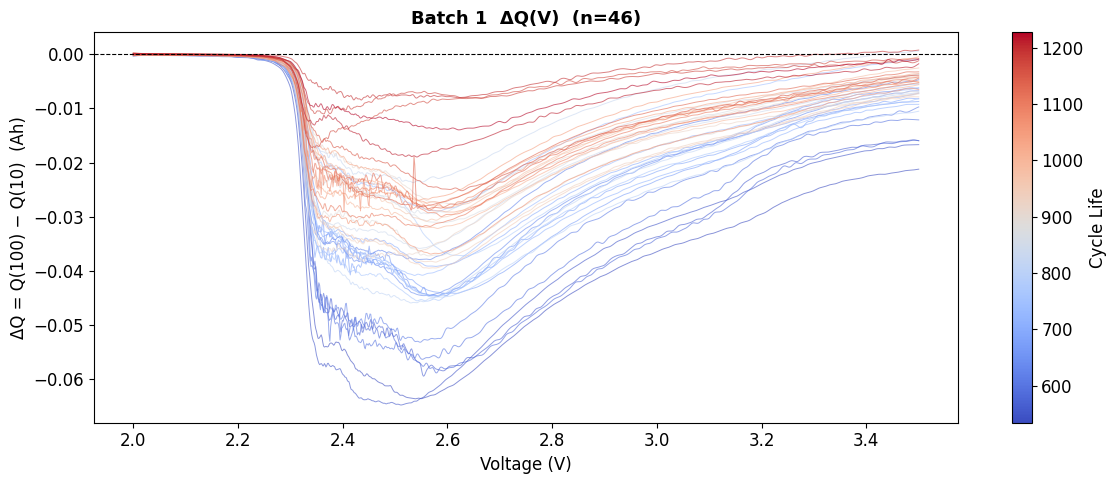

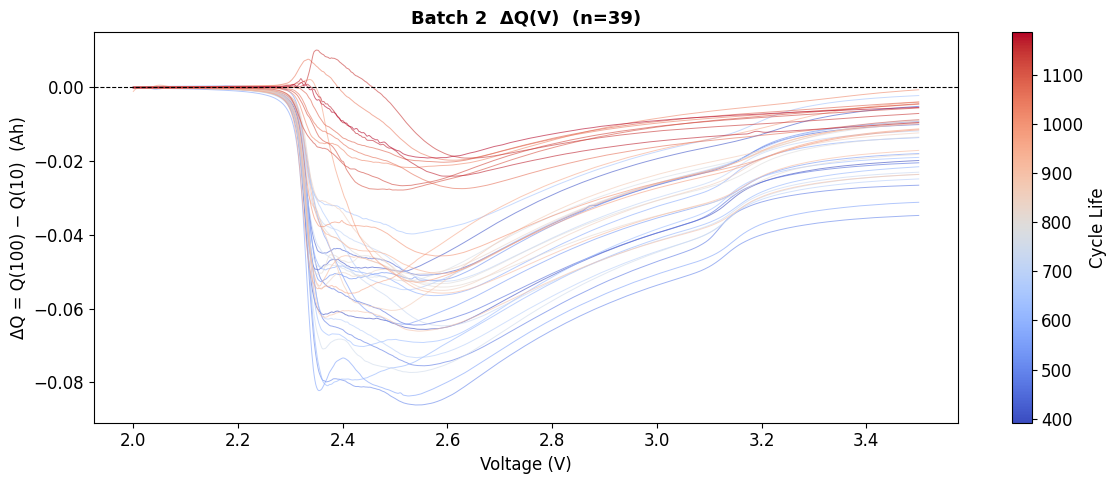

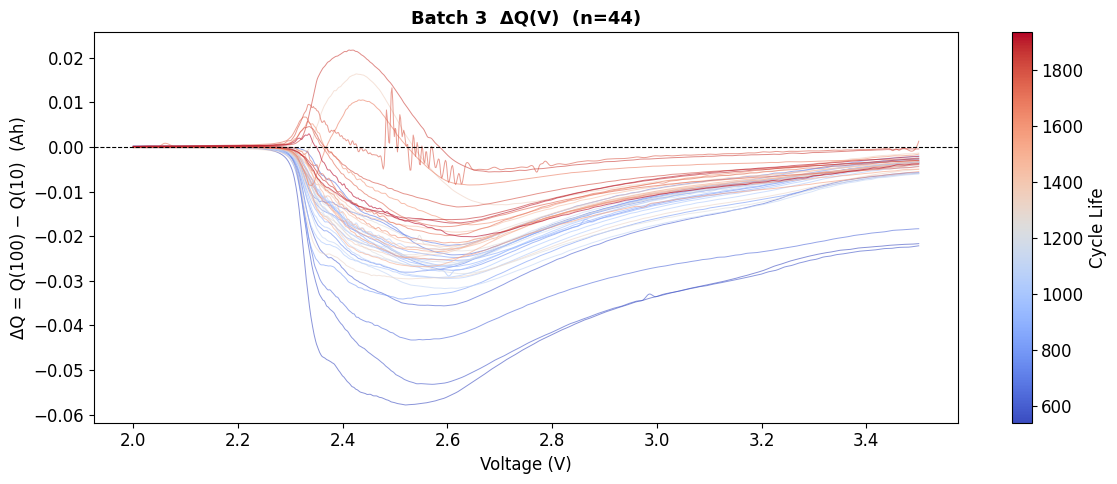

In [40]:
# ── 1. 배치별 ΔQ(V) 곡선 전체 ──────────────────────────────────
for bname, dq in [('Batch 1', dQ1), ('Batch 2', dQ2), ('Batch 3', dQ3)]:
    lives  = np.array([d['cycle_life'] for d in dq])
    colors = cm.coolwarm(np.linspace(0, 1, len(dq)))
    order  = np.argsort(lives)

    fig, ax = plt.subplots(figsize=(12, 5))

    for rank, idx in enumerate(order):
        ax.plot(dq[idx]['V'], dq[idx]['dQ'],
                color=colors[rank], linewidth=0.7, alpha=0.6)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Voltage (V)')
    ax.set_ylabel('ΔQ = Q(100) − Q(10)  (Ah)')
    ax.set_title(f'{bname}  ΔQ(V)  (n={len(dq)})', fontsize=13, fontweight='bold')

    sm = cm.ScalarMappable(cmap='coolwarm',
         norm=plt.Normalize(vmin=lives.min(), vmax=lives.max()))
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label='Cycle Life')

    plt.tight_layout()
    plt.show()


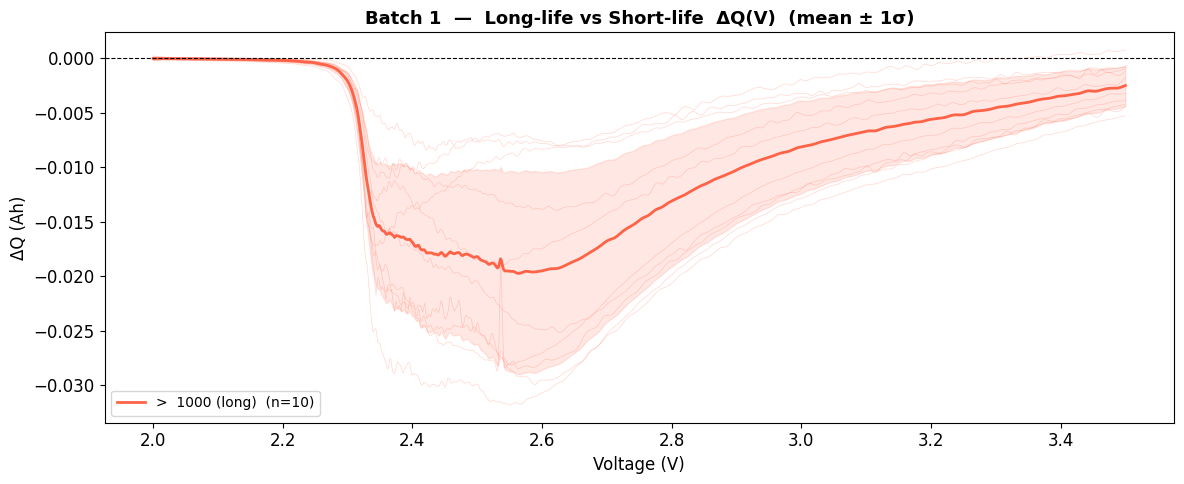

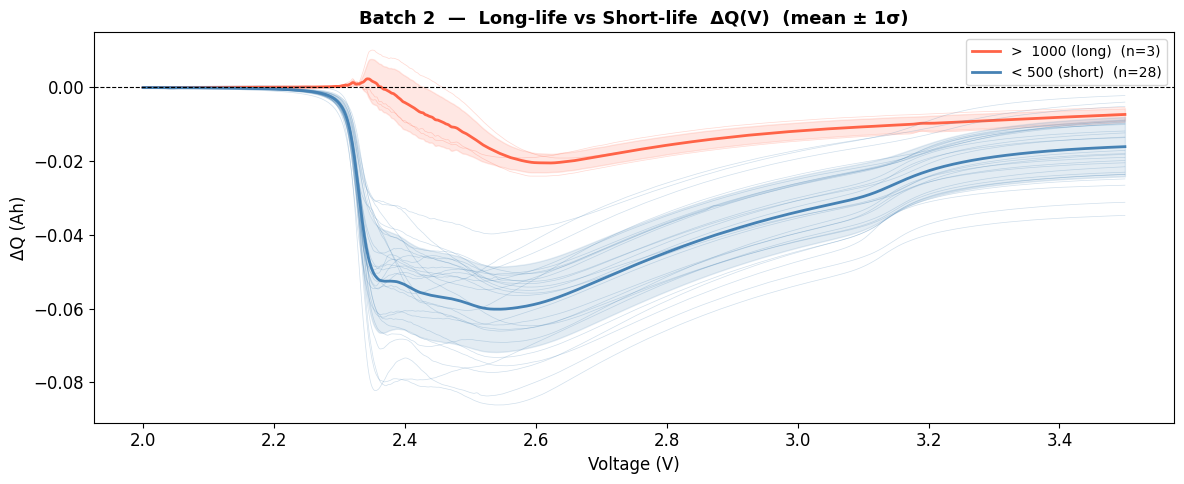

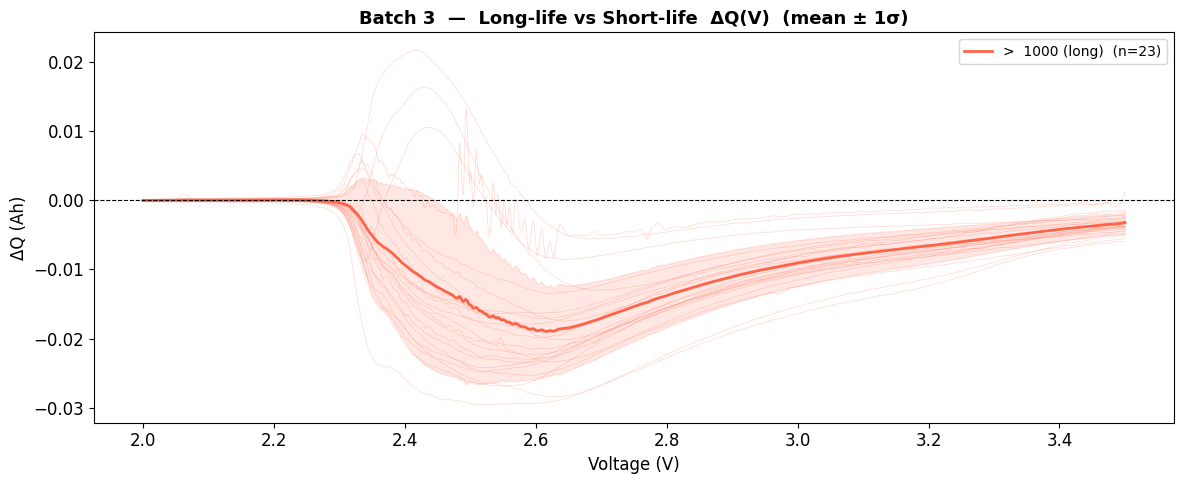

In [41]:
# ── 2. 장수명(>1000) vs 단수명(<500) ΔQ 형태 비교 ──────────────
LONG_TH  = 1000
SHORT_TH = 500

for bname, dq in [('Batch 1', dQ1), ('Batch 2', dQ2), ('Batch 3', dQ3)]:
    long_cells  = [d for d in dq if d['cycle_life'] >  LONG_TH]
    short_cells = [d for d in dq if d['cycle_life'] < SHORT_TH]

    fig, ax = plt.subplots(figsize=(12, 5))

    def plot_group(cells, color, label):
        if not cells:
            return
        V   = cells[0]['V']
        mat = np.vstack([d['dQ'] for d in cells])
        mean = mat.mean(axis=0)
        std  = mat.std(axis=0)
        for row in mat:
            ax.plot(V, row, color=color, linewidth=0.5, alpha=0.25)
        ax.plot(V, mean, color=color, linewidth=2.0,
                label=f'{label}  (n={len(cells)})')
        ax.fill_between(V, mean - std, mean + std, color=color, alpha=0.15)

    plot_group(long_cells,  'tomato', f'>  {LONG_TH} (long)')
    plot_group(short_cells, 'steelblue',    f'< {SHORT_TH} (short)')

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Voltage (V)')
    ax.set_ylabel('ΔQ (Ah)')
    ax.set_title(f'{bname}  —  Long-life vs Short-life  ΔQ(V)  (mean ± 1σ)',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()


batch             Batch 1  Batch 2  Batch 3
cell_id    count   46.000   39.000   44.000
           mean    22.500   20.795   22.273
           std     13.423   13.744   13.652
           min      0.000    0.000    0.000
           25%     11.250    9.500   10.750
...                   ...      ...      ...
dQ_min_loc min      2.347    2.357    2.341
           25%      2.539    2.517    2.565
           50%      2.564    2.541    2.595
           75%      2.581    2.586    2.612
           max      2.635    2.638    2.689

[72 rows x 3 columns]

[피처 × cycle_life  Pearson r  (전체 배치 합산)]
  dQ_min               : +0.827
  log_dQ_var           : -0.851
  dQ_skew              : -0.026
  dQ_kurt              : +0.365
  dQ_min_loc           : +0.240


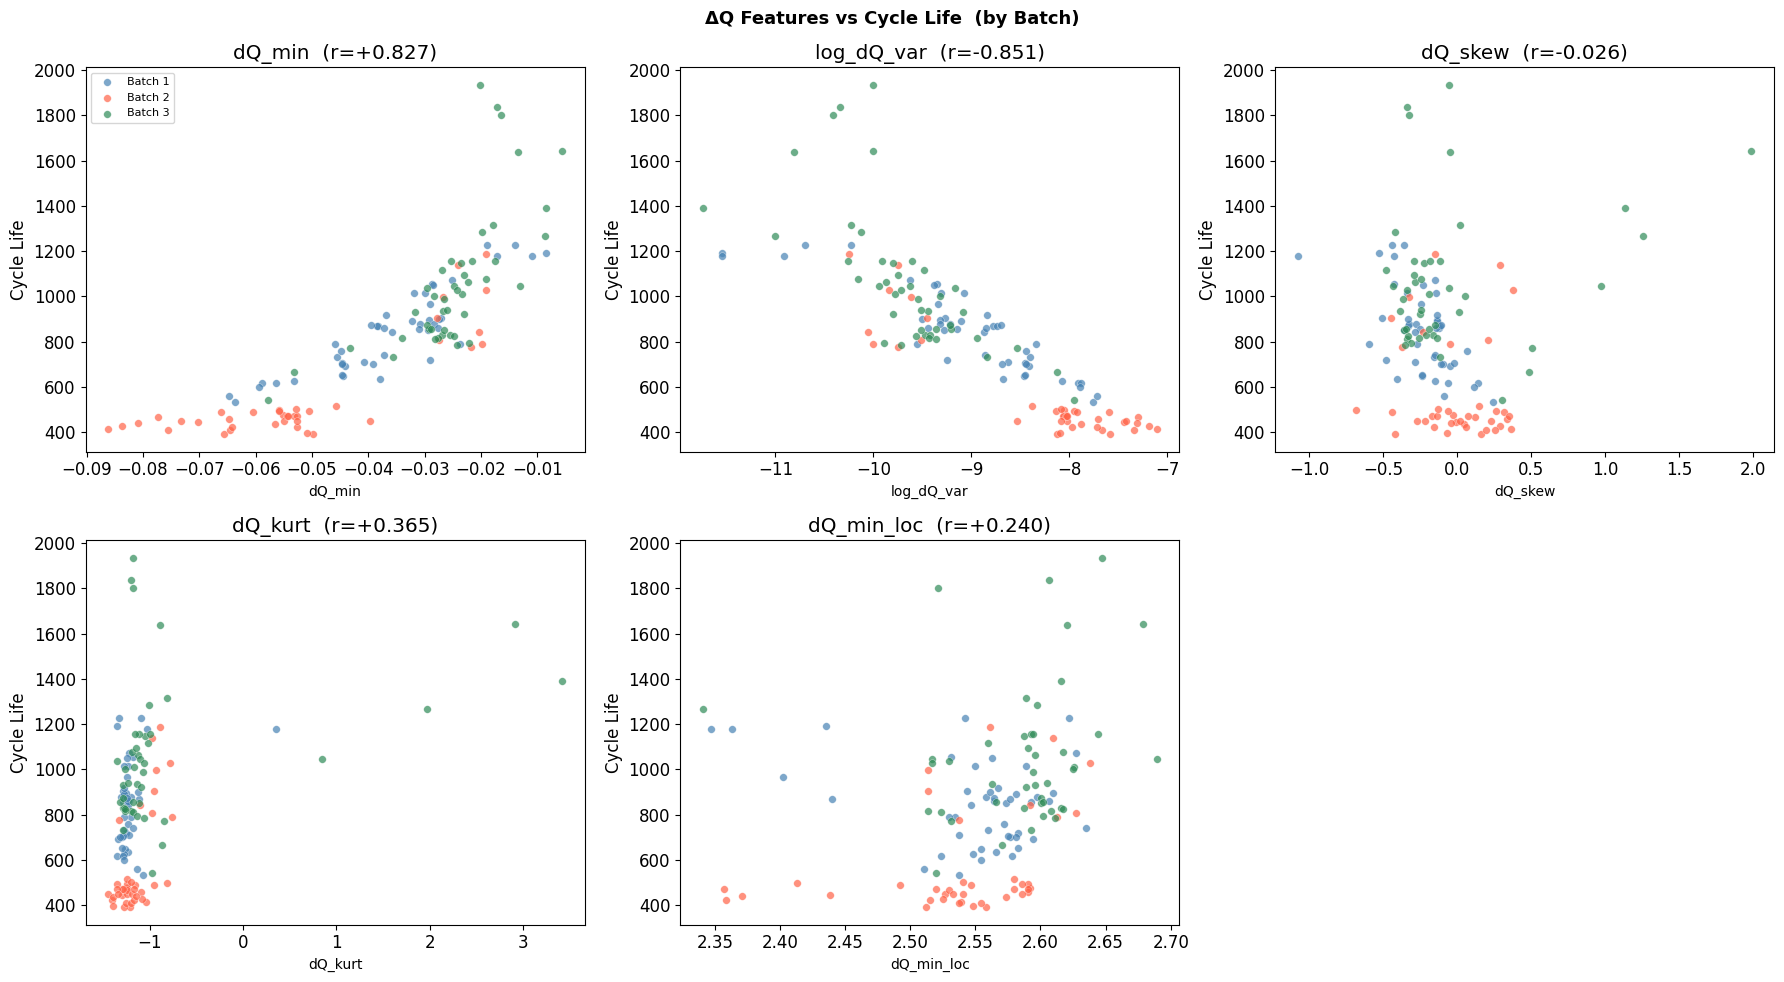

In [42]:
# ── 3. ΔQ 통계 피처 추출 ─────────────────────────────────────
def dQ_features(dq_list, batch_name):
    rows = []
    for d in dq_list:
        x = d['dQ']
        rows.append({
            'batch'        : batch_name,
            'cell_id'      : d['cell_id'],
            'cycle_life'   : d['cycle_life'],
            'dQ_min'       : x.min(),
            'dQ_mean'      : x.mean(),
            'dQ_var'       : x.var(),
            'log_dQ_var'   : np.log(x.var() + 1e-10),
            'dQ_skew'      : skew(x),
            'dQ_kurt'      : kurtosis(x),
            'dQ_min_loc'   : d['V'][np.argmin(x)],   # 최솟값 위치 전압
        })
    return pd.DataFrame(rows)

feat1 = dQ_features(dQ1, 'Batch 1')
feat2 = dQ_features(dQ2, 'Batch 2')
feat3 = dQ_features(dQ3, 'Batch 3')
feat_all = pd.concat([feat1, feat2, feat3], ignore_index=True)

print(feat_all.groupby('batch').describe().round(3).T)

# ── 피처별 cycle_life 산점도 (3 / 2 배치) ────────────────────
feat_cols  = ['dQ_min', 'log_dQ_var', 'dQ_skew', 'dQ_kurt', 'dQ_min_loc']
colors_map = {'Batch 1': 'steelblue', 'Batch 2': 'tomato', 'Batch 3': 'seagreen'}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# 마지막 칸(2행 3열) 비우기
axes[1, 2].set_visible(False)
ax_list = [axes[0,0], axes[0,1], axes[0,2], axes[1,0], axes[1,1]]

for ax, col in zip(ax_list, feat_cols):
    for bname, grp in feat_all.groupby('batch'):
        ax.scatter(grp[col], grp['cycle_life'],
                   label=bname, alpha=0.7, s=30,
                   color=colors_map[bname], edgecolors='white', linewidths=0.3)
    r = feat_all[col].corr(feat_all['cycle_life'])
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Cycle Life')
    ax.set_title(f'{col}  (r={r:+.3f})')

ax_list[0].legend(fontsize=8)

# Pearson r 출력
print("\n[피처 × cycle_life  Pearson r  (전체 배치 합산)]")
for col in feat_cols:
    r = feat_all[col].corr(feat_all['cycle_life'])
    print(f"  {col:20s} : {r:+.3f}")

plt.suptitle('ΔQ Features vs Cycle Life  (by Batch)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()